# Comparing WGCNA modules across phases
Through WGCNA, I identified significantly correlated modules with treatments/growth in both phase 1 and phase 2 oysters. In this notebook, I want to dig deeper into the identified modules and see if there are overlapping genes between similarly correlated modules in phase 1 and 2 oysters.

## 0. load libraries

In [2]:
library(tidyverse)
library(RColorBrewer)
library(rtracklayer)
library(pheatmap)

## 1. read CSVs
these module outputs come from the [phase 1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) and [phase 2](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/prefilter_newRef_wgcna_p2.ipynb) WGCNA analyses.

#### phase 1 oysters 

module information

In [3]:
p1_geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv')
head(p1_geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.282186775,0.06994163,0.1492213,0.385003047,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.4217885,-0.363072643,-0.28138410,-0.24659525,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.065239565,0.07719106,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.303838275,-0.01706141,-0.2141764,0.221972568,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.37935688,-0.49934818,0.05801009,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.310348052,-0.04403876,0.3171945,0.004370064,0.34594159,0.31502257,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876548,0.07063991,0.365824475,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,-0.35176148,-0.282846525,-0.03894228,-0.0592647,-0.254057873,0.06198487,-0.01882029,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867298,0.47087567,-0.253669949,0.40577513,0.03737518,0.72387889,0.49103455
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.181368789,-0.15299170,-0.3250255,0.370840965,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.33485347,-0.05929480,-0.20905792,-0.29068175


vst expression

In [4]:
p1_vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv') %>%
dplyr::rename('Gene' = X) %>%
# convert to long format
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst_expr'
    )

head(p1_vst)

Gene,Sample,vst_expr
<chr>,<chr>,<dbl>
LOC144621260,B1_Nu_O03,11.21797
LOC144621260,B2_Nu_O12,11.93477
LOC144621260,B4_Nu_O32,11.22476
LOC144621260,B5_Nu_O36,11.38600
LOC144621260,B6_Nu_O47,11.49149
LOC144621260,C1_Nu_W01,11.33041


#### phase 2 oysters

module information

In [5]:
p2_geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_GeneInfo.csv')
head(p2_geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green,0.14571142,0.05937969,-0.109564792,-0.12499754,-0.01985215,-0.128608602,-0.05370241,⋯,0.009638715,0.14857330,0.150462603,0.0014763335,0.10330871,0.20884429,0.07217231,-0.058705838,-0.063588526,-0.168151337
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black,0.02275339,-0.06710301,-0.113811162,0.01333703,0.03823132,-0.004338504,0.15336122,⋯,0.134078073,-0.12596425,-0.169428680,0.0001014633,-0.07418067,0.04122113,-0.07353120,-0.008073588,0.075545608,0.009819899
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,black,-0.02129411,-0.03599048,-0.009529534,0.19284124,0.10132621,0.163054335,0.15998130,⋯,0.209695014,0.07264407,-0.093507897,-0.1093702268,-0.03710835,0.24539274,0.12959445,-0.109145432,-0.007852902,-0.065906431
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black,-0.04812120,-0.10076555,-0.011929654,0.12670143,0.14377818,0.068519391,0.35017609,⋯,0.045893617,0.01785133,0.074087246,0.2533965011,0.19857920,0.46199620,0.11825447,0.009861154,0.276834705,-0.247062909
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green,-0.05057534,-0.03567957,-0.078227407,0.02812682,0.12377098,-0.030726663,0.16142128,⋯,0.099713237,-0.01010121,-0.061427955,-0.0005536777,0.16424719,0.45477782,0.17354495,0.095553785,0.018403605,-0.155316540
6,LOC111099048,GO:0000302;GO:0005737;GO:0006629;GO:0031409,yellow,-0.03194334,-0.17166732,-0.142415748,0.01994378,-0.05197196,0.048096172,-0.04022407,⋯,-0.127597289,0.01079934,-0.006241344,-0.0653833675,0.07945784,0.03267339,-0.01281366,0.108991599,0.054429507,-0.021963826


vst expression

In [6]:
p2_vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv') %>%
dplyr::rename('Gene' = X) %>%
# convert to long format
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst_expr'
    )


head(p2_vst)

Gene,Sample,vst_expr
<chr>,<chr>,<dbl>
LOC144621260,B1_B1_O01,11.62347
LOC144621260,B1_W5_O50,11.42347
LOC144621260,B2_B5_O51,11.40884
LOC144621260,B2_C4_O40,11.27515
LOC144621260,B3_B4_O41,11.00057
LOC144621260,B3_C3_O30,10.98404


### oyster meta data 

In [7]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


## 2. compare modules

In phase 1 oysters, there are only 3 significant modules:
- red, which is negatively correlated with tissue growth
- blue, which is positively correlateed with shell growth and the warm treatment
- black, which negatively correlated with temperature

I think the easiest way to compare modules is to pull out the matching genes for the phase 1 modules, and see if they're coming from the same module in phase 2


## 2a. phase 1 red module

In [8]:
p1red <- p1_geneInfo %>% filter(ModuleColor == 'red')
dim(p1red)
head(p1red)

p1red.geneList <- p1red %>% pull(Gene)
head(p1red.geneList)

[1] 714  34

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.31034805,-0.04403876,0.31719449,0.004370064,0.34594159,0.315022568,⋯,-0.45300723,-0.5109126,-0.3118285,-0.07876548,0.07063991,0.36582448,0.5063826,0.3236889,0.4028827,0.6802280
2,LOC111099693,GO:0003713;GO:0042800;GO:0044666;GO:0045944,red,-0.40472129,-0.21510355,0.07624957,0.27614768,0.133768594,0.23619272,0.184311916,⋯,-0.31462488,-0.7529479,-0.4508056,-0.51306302,0.08572571,0.07119193,0.4887200,0.3557724,0.7204733,0.8257951
3,LOC111099735,GO:0016192;GO:0046872;GO:0071782;GO:0071787;GO:0072659,red,0.01973772,0.15863297,0.24399899,0.08599462,-0.007219988,0.09799063,0.110865878,⋯,-0.30797509,-0.4606492,-0.1071672,-0.39091269,-0.01699828,0.43312495,0.5656473,0.4018363,0.3709339,0.4719244
4,LOC111099746,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,red,-0.13193244,-0.06459774,0.03766456,0.11703581,0.072317328,0.09229022,0.110106311,⋯,-0.19314713,-0.8203041,-0.5346497,-0.19434305,0.19222201,-0.03246489,0.3296064,0.2200731,0.8200251,0.7850884
5,LOC111099748,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,red,0.12584809,0.17526897,0.13254837,-0.02414464,0.015087173,-0.03404276,0.001331461,⋯,-0.07628865,-0.6263643,-0.2661227,-0.31150067,-0.01546547,-0.02108352,0.3775180,0.3486656,0.5265380,0.5888553
6,LOC111099814,GO:0003677;GO:0006310;GO:0015074,red,-0.01134809,0.14115925,0.21767435,-0.12643038,0.132882244,-0.20520073,-0.143742022,⋯,-0.04431040,-0.3213722,-0.2295507,-0.32752582,-0.02938513,-0.09819086,0.1399721,0.1696643,0.2970881,0.3547488


[1] "LOC111099041" "LOC111099693" "LOC111099735" "LOC111099746" "LOC111099748"
[6] "LOC111099814"

now looking for overlap in phase 2 oysters

In [9]:
p1_inRed <- p2_geneInfo[p2_geneInfo$Gene %in% p1red.geneList, ]

head(p1_inRed)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black,-0.0481212,-0.10076555,-0.01192965,0.126701429,0.14377818,0.06851939,0.350176093,⋯,0.04589362,0.01785133,0.07408725,0.25339650,0.19857920,0.46199620,0.11825447,0.009861154,0.27683471,-0.24706291
21,LOC111099693,GO:0003713;GO:0042800;GO:0044666;GO:0045944,green,-0.2074532,-0.18172561,-0.06556275,0.033833684,0.09514336,-0.01008444,0.158271238,⋯,-0.21251199,0.19848009,0.02981323,0.05563639,0.44011006,0.67102278,0.27303683,-0.110695437,0.21151600,-0.10231388
34,LOC111099735,GO:0016192;GO:0046872;GO:0071782;GO:0071787;GO:0072659,black,-0.0544576,0.08033712,0.18791073,-0.033531628,-0.02927387,-0.02252331,0.121661056,⋯,0.35496259,-0.14160917,0.09862876,0.09516957,-0.24377433,0.09336093,0.04718969,-0.038828453,0.11186453,-0.07475574
38,LOC111099746,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,green,-0.1040857,-0.10432745,0.01496226,-0.010474090,-0.03559929,0.00619523,0.008747655,⋯,0.23380129,0.01395875,0.37061173,0.07945120,-0.04101680,0.40141663,0.22850015,-0.086051460,-0.11370622,-0.27010033
39,LOC111099748,GO:0005524;GO:0016020;GO:0016887;GO:0055085;GO:0140359,turquoise,-0.1395856,-0.19310325,-0.28668906,0.132238534,0.06195999,0.11557503,0.219077407,⋯,0.26524599,0.06543570,0.14750798,0.04601027,-0.10274431,0.33978608,0.10702138,0.209628035,0.02501241,-0.14406981
56,LOC111099814,GO:0003677;GO:0006310;GO:0015074,green,0.0288145,-0.12251379,-0.20295507,-0.005681686,-0.13133931,0.05938806,0.009932684,⋯,0.04462049,-0.07730521,0.07815195,0.06791813,0.05459322,0.20214457,0.13367824,-0.130110521,-0.08819711,-0.01930354


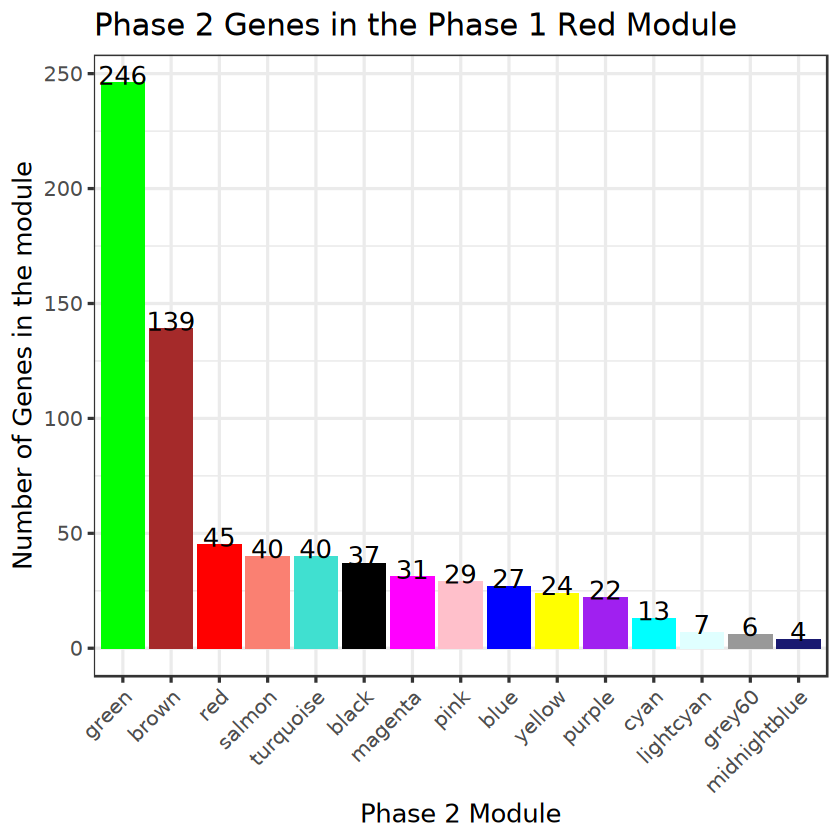

In [10]:
ggplot(p1_inRed, aes(x = fct_infreq(ModuleColor), fill = ModuleColor)) +
geom_bar() + 
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_fill_identity() +
labs(x = 'Phase 2 Module',
     y = 'Number of Genes in the module',
     title = 'Phase 2 Genes in the Phase 1 Red Module')

so for the phase 1 module, the majority of genes are assigned to the green and brown modules in phase 2 oysters

in phase 2 modules:
- green is negatively correlated with late control and positively correlated with late warm and hypoxic
- brown is positively correlated with late hypoxic and negatively correlated with late both

as a reminder, this phase 1 red module is negatively correlated with tissue growth (increased tissue growth is associated with lower expression)

not sure what to make of this? i'm wondering if the genes that overlap are part of the group that have high correlation with tissue growth or if they are more "on the fringe" of that module. Would be interested to look closer at the phase 2 growth - do similar patterns emerge in phase 2 as in phase 1? if there are not strong differences in growth for phase 2 oysters, that could explain why we don't see a correlation for growth. But I'm still confused how these genes could contribute to growth early on and then "switch" later ... so what else are they doing and/or how are they contributing to oyster resilience?

Thinking about what WGCNA actually aims to do - group genes that are likely in the same network since their changes in expression are similar - we see the gene network changes in phase 2 oysters, since the red module phase 1 genes are spread across numerous modules -> so there's a switch-up of the network/which genes are interacting with each other? is this likely/is there evidence of this elsewhere?

## 2b. phase 1 blue module
positively correlated with shell growth and the warm treatment

In [11]:
p1blue <- p1_geneInfo %>% filter(ModuleColor == 'blue')
dim(p1blue)
head(p1blue)

p1blue.geneList <- p1blue %>% pull(Gene)
head(p1blue.geneList)

[1] 1149   34

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.28218678,0.06994163,0.14922130,0.3850030,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.4632480,-0.1964876,0.05033161,-0.0408578
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.30383828,-0.01706141,-0.21417645,0.2219726,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.3793569,-0.4993482,0.05801009,-0.3537447
3,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.18136879,-0.15299170,-0.32502548,0.3708410,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.3348535,-0.0592948,-0.20905792,-0.2906817
4,LOC111099056,GO:0003723;GO:0006396;GO:0008173,blue,0.04069859,-0.30133511,-0.51408511,-0.01745328,0.1796366,-0.10897360,0.16182627,⋯,0.3682074,0.39044085,0.34971161,0.13520826,0.02919966,-0.232942601,-0.1765975,-0.1843648,-0.32814622,-0.4027504
5,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,0.33300808,-0.03349318,-0.33539153,-0.21150007,0.3037352,-0.38399271,-0.04497754,⋯,0.8119506,0.15137962,0.23177091,-0.02246380,-0.46009687,-0.489748111,-0.4097593,0.0993402,-0.32602950,-0.1226918
6,LOC111099690,GO:0009226;GO:0050577,blue,0.46954235,0.17402822,-0.18741587,-0.27288364,0.3555786,-0.47728398,-0.13737441,⋯,0.9453898,0.37388748,0.70708931,-0.15422990,-0.71079105,-0.265672565,-0.1406753,0.3713513,-0.60635522,-0.2966610


[1] "LOC111099029" "LOC111099039" "LOC111099053" "LOC111099056" "LOC111099067"
[6] "LOC111099690"

now looking for overlap in phase 2 oysters

In [12]:
p2_inp1Blue <- p2_geneInfo[p2_geneInfo$Gene %in% p1blue.geneList, ]

head(p2_inp1Blue)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green,0.14571142,0.059379691,-0.10956479,-0.124997539,-0.01985215,-0.128608602,-0.053702410,⋯,0.009638715,0.14857330,0.1504626,0.0014763335,0.10330871,0.20884429,0.072172309,-0.058705838,-0.063588526,-0.168151337
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black,0.02275339,-0.067103011,-0.11381116,0.013337034,0.03823132,-0.004338504,0.153361219,⋯,0.134078073,-0.12596425,-0.1694287,0.0001014633,-0.07418067,0.04122113,-0.073531205,-0.008073588,0.075545608,0.009819899
8,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.10442432,0.009228049,-0.13707128,-0.071708546,-0.17211395,0.006601442,-0.305828154,⋯,0.462452514,-0.01550298,0.1943757,-0.0899308075,-0.62950997,-0.54753731,-0.009128044,0.101348558,-0.630685232,-0.105946739
10,LOC111099056,GO:0003723;GO:0006396;GO:0008173,yellow,0.06918981,-0.016217597,-0.13764189,0.017576617,0.18000517,-0.070543379,-0.009757955,⋯,-0.069742690,0.09167718,0.1523025,0.1265533835,-0.06227758,-0.24645994,-0.283579280,0.133678133,0.001086335,-0.148705562
16,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,-0.03422454,-0.076835946,-0.18809729,0.000304824,-0.16451563,0.082615102,-0.071456819,⋯,0.385565192,0.05052735,0.1861722,0.0924502620,-0.31667544,-0.04596036,0.557500209,-0.035670470,-0.507028280,0.046035591
19,LOC111099690,GO:0009226;GO:0050577,blue,0.11863038,0.091305616,0.02966622,-0.079212028,0.05683602,-0.116216845,-0.361268415,⋯,0.182370459,-0.12416529,0.1068800,-0.1610044397,-0.36510010,-0.50192748,-0.356096096,0.005860285,-0.387830639,-0.137380285


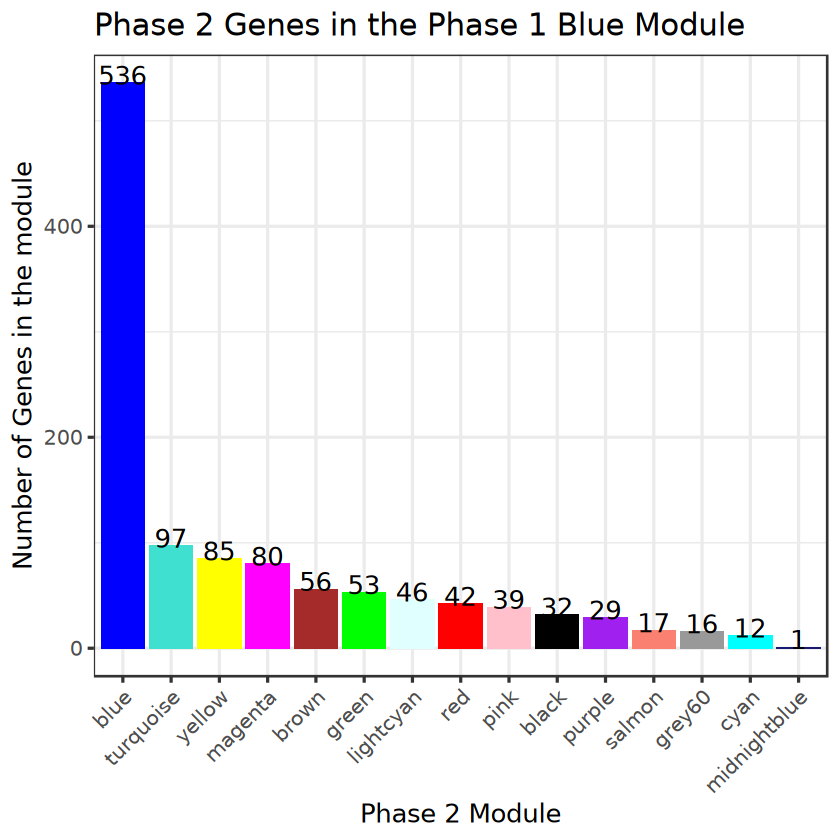

In [13]:
ggplot(p2_inp1Blue, aes(x = fct_infreq(ModuleColor), fill = ModuleColor)) +
geom_bar() + 
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_fill_identity() +
labs(x = 'Phase 2 Module',
     y = 'Number of Genes in the module',
     title = 'Phase 2 Genes in the Phase 1 Blue Module')

This is promising! About half of the genes in the phase 1 blue module are in the same phase 2 module - so likely that these are actually connected in a network. 

in phase 2 oysters, the blue module is:
- positively correlated with tissue and shell growth
- negatively correlated with phase 2 DO and temp
- positively correlated with phase 2 control treatment
- negatively correlated with phase 2 warm treatment

in phase 1 oysters, the blue module is:
- positively correlated with shell growth and the warm treatment

hmmmm so this is interesting! We see a continuation of these genes influencing shell growth (both positive correlations), so it's likely these genes are contributing to increased shell growth (but how to reconcile that they also are now correlated with tissue growth? should check out the phase 2 growth data more closely, do both shell and tissue growth show similar patterns/change in similar ways?)

BUT we see a switch of correlation direction with the most recent warm treatment exposure - in phase 1, there was a positive correlation (higher expression of these genes in warm) and in phase 2, there was a negative correlation (lower expression of these genes in warm) - what could this mean?
- evidence of transcriptional frontloading? maybe not, because for phase 2 oysters we're ignoring phase 1, so we don't know if these oysters experienced warming twice
- identification of timing-specific genes? plasticity in the response of these genes? the response of these genes may depend on the timing of when warm stress was experienced

should look into the exact expression patterns (with phase 1 context) in the phase 2 oysters to parse this out a bit more!

### deeper dive - pulling shared genes
pulling the phase 2 module with the majority of the genes in the phase 1 blue module

In [14]:
geneList536 <- p2_inp1Blue %>% filter(ModuleColor == 'blue') %>% pull(Gene)

length(geneList536)

[1] 536

plot expression of these genes in phase 2 oysters

In [15]:
vst536 <- p2_vst[p2_vst$Gene %in% geneList536,]

# check number of genes and preview df
length(unique(vst536$Gene))
head(vst536)

[1] 536

Gene,Sample,vst_expr
<chr>,<chr>,<dbl>
LOC111103667,B1_B1_O01,10.61483
LOC111103667,B1_W5_O50,10.74662
LOC111103667,B2_B5_O51,10.57260
LOC111103667,B2_C4_O40,10.86618
LOC111103667,B3_B4_O41,10.80966
LOC111103667,B3_C3_O30,10.64225


In [16]:
# add meta data
vst536.meta <- merge(vst536, meta, by = 'Sample')
head(vst536.meta)

,Sample,Gene,vst_expr,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,LOC111103667,10.614826,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_B1_O01,LOC111133163,10.062262,both,warm,hypoxic,1,both,warm,hypoxic,1
3,B1_B1_O01,LOC111116995,11.043960,both,warm,hypoxic,1,both,warm,hypoxic,1
4,B1_B1_O01,LOC144625428,9.777704,both,warm,hypoxic,1,both,warm,hypoxic,1
5,B1_B1_O01,LOC111104297,8.611885,both,warm,hypoxic,1,both,warm,hypoxic,1
6,B1_B1_O01,LOC111137959,9.895566,both,warm,hypoxic,1,both,warm,hypoxic,1


#### vst in phase 2

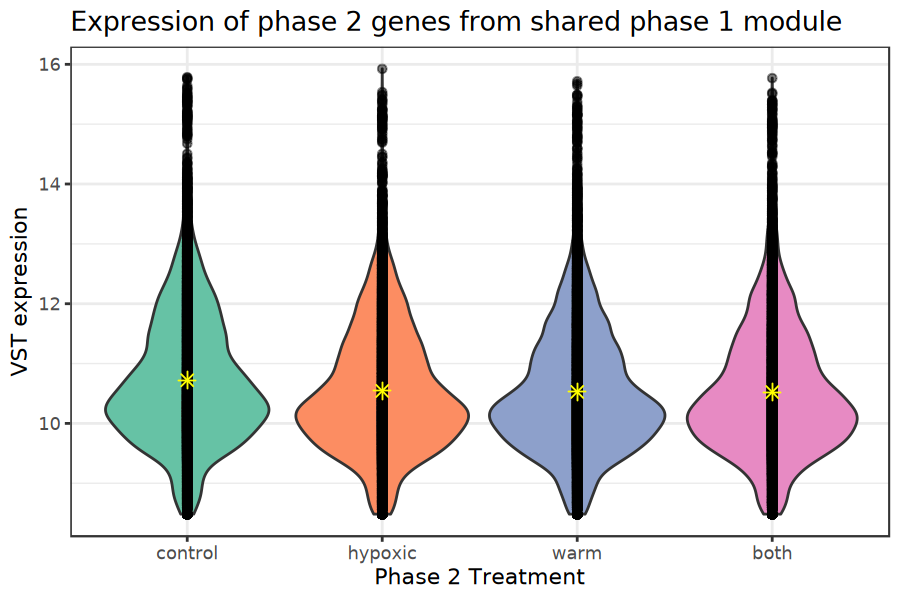

In [17]:
options(repr.plot.width = 7.5, repr.plot.height = 5 )

# set factors
vst536.meta$Phase1_treatment <- factor(vst536.meta$Phase1_treatment, levels = c('control', 'hypoxic', 'warm', 'both'))
vst536.meta$Phase2_treatment <- factor(vst536.meta$Phase2_treatment, levels = c('control', 'hypoxic', 'warm', 'both'))


ggplot(vst536.meta, aes(x = Phase2_treatment, y = vst_expr, fill = Phase2_treatment)) +
geom_violin() +
geom_point(alpha=0.5) +
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 13) +
guides(fill = 'none') +
labs(x = 'Phase 2 Treatment',
     y = 'VST expression',
     title = 'Expression of phase 2 genes from shared phase 1 module')

so just looking at phase 2 treatment, it appears that the average expression of each treatment is more or less the same, so this isn't super informative

(actually looking at this now, it's not informative bc in the heatmap I'm able to scale each row so that genes that have really high expression don't hide smaller changes in gene expression. so the reason this doesn't show overall higher gene expression is bc all genes are "on the same playing field", so even if genes have typically higher GE in control or whatever, you won't be able to see it here)

might be better to look at a gene expression heatmap?

#### vst heatmap in phase 2

In [24]:
vst536.matrix <- p2_vst %>% 
pivot_wider(
    names_from = Sample,
    values_from = vst_expr
    ) %>%
column_to_rownames('Gene')

# pull out only the 536 genes I'm interested in
vst536.matrix <- vst536.matrix[rownames(vst536.matrix) %in% vst536.meta$Gene,]

dim(vst536.matrix)
head(vst536.matrix)

[1] 536  92

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111103667,10.614826,10.746625,10.572600,10.866185,10.809657,10.642249,10.862753,10.606639,10.315092,10.609138,⋯,10.443846,10.520873,10.70998,10.617699,10.531349,10.449535,10.631321,10.757137,10.600756,10.600267
LOC144621561,9.335328,8.591535,8.770966,9.009570,9.053807,8.743216,9.014902,9.764684,8.596820,8.969056,⋯,8.620787,9.001139,8.63052,8.483578,8.819568,8.594679,8.483578,8.679812,9.151383,8.788137
LOC111105167,8.483578,8.483578,9.705856,9.112477,8.483578,9.274958,9.150680,8.483578,8.483578,8.483578,⋯,8.595623,8.917830,10.25313,8.560190,9.414148,8.562148,8.483578,8.483578,8.970752,8.641066
LOC111103981,10.360167,10.216399,10.180265,10.222425,10.213334,10.067553,10.577707,10.045641,10.143461,9.847179,⋯,10.144529,10.058328,10.49404,10.052072,10.240677,9.748160,9.931690,10.124417,10.068329,10.165814
LOC111104297,8.611885,8.615783,8.483578,9.500785,9.222464,9.211201,9.128244,8.483578,8.748849,9.111388,⋯,8.845783,9.169738,9.13008,9.087318,9.053794,9.259968,8.766742,9.134300,9.294254,8.562351
LOC111104038,10.587033,10.403215,10.331027,10.133312,10.270679,10.122502,10.664332,10.369290,9.657661,9.703274,⋯,10.167253,9.861443,10.17537,10.044306,10.411463,9.896511,10.931424,10.168184,10.164263,10.195144


In [38]:
meta2 <- meta %>%
mutate(complete_treatment = paste(Phase1_treatment, Phase2_treatment))

head(meta2)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA,both NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA,both NA


In [48]:
annotation <- meta2 %>%
  dplyr::select(Sample, Phase1_treatment, Phase2_treatment) %>%
  column_to_rownames("Sample") 

annotation_colors <- list(
    Phase2_treatment = setNames(
    brewer.pal(4, "Set2"),
    c("control", "hypoxic", "warm", "both")
  ),
  Phase1_treatment = setNames(
    brewer.pal(4, "Set2"),
    c("control", "hypoxic", "warm", "both")
  )
)


head(annotation)

,Phase1_treatment,Phase2_treatment
,<chr>,<chr>
B1_B1_O01,both,both
B1_Nu_O03,both,NA
B1_W5_O50,both,warm
B2_B5_O51,both,both
B2_C4_O40,both,control
B2_Nu_O12,both,NA


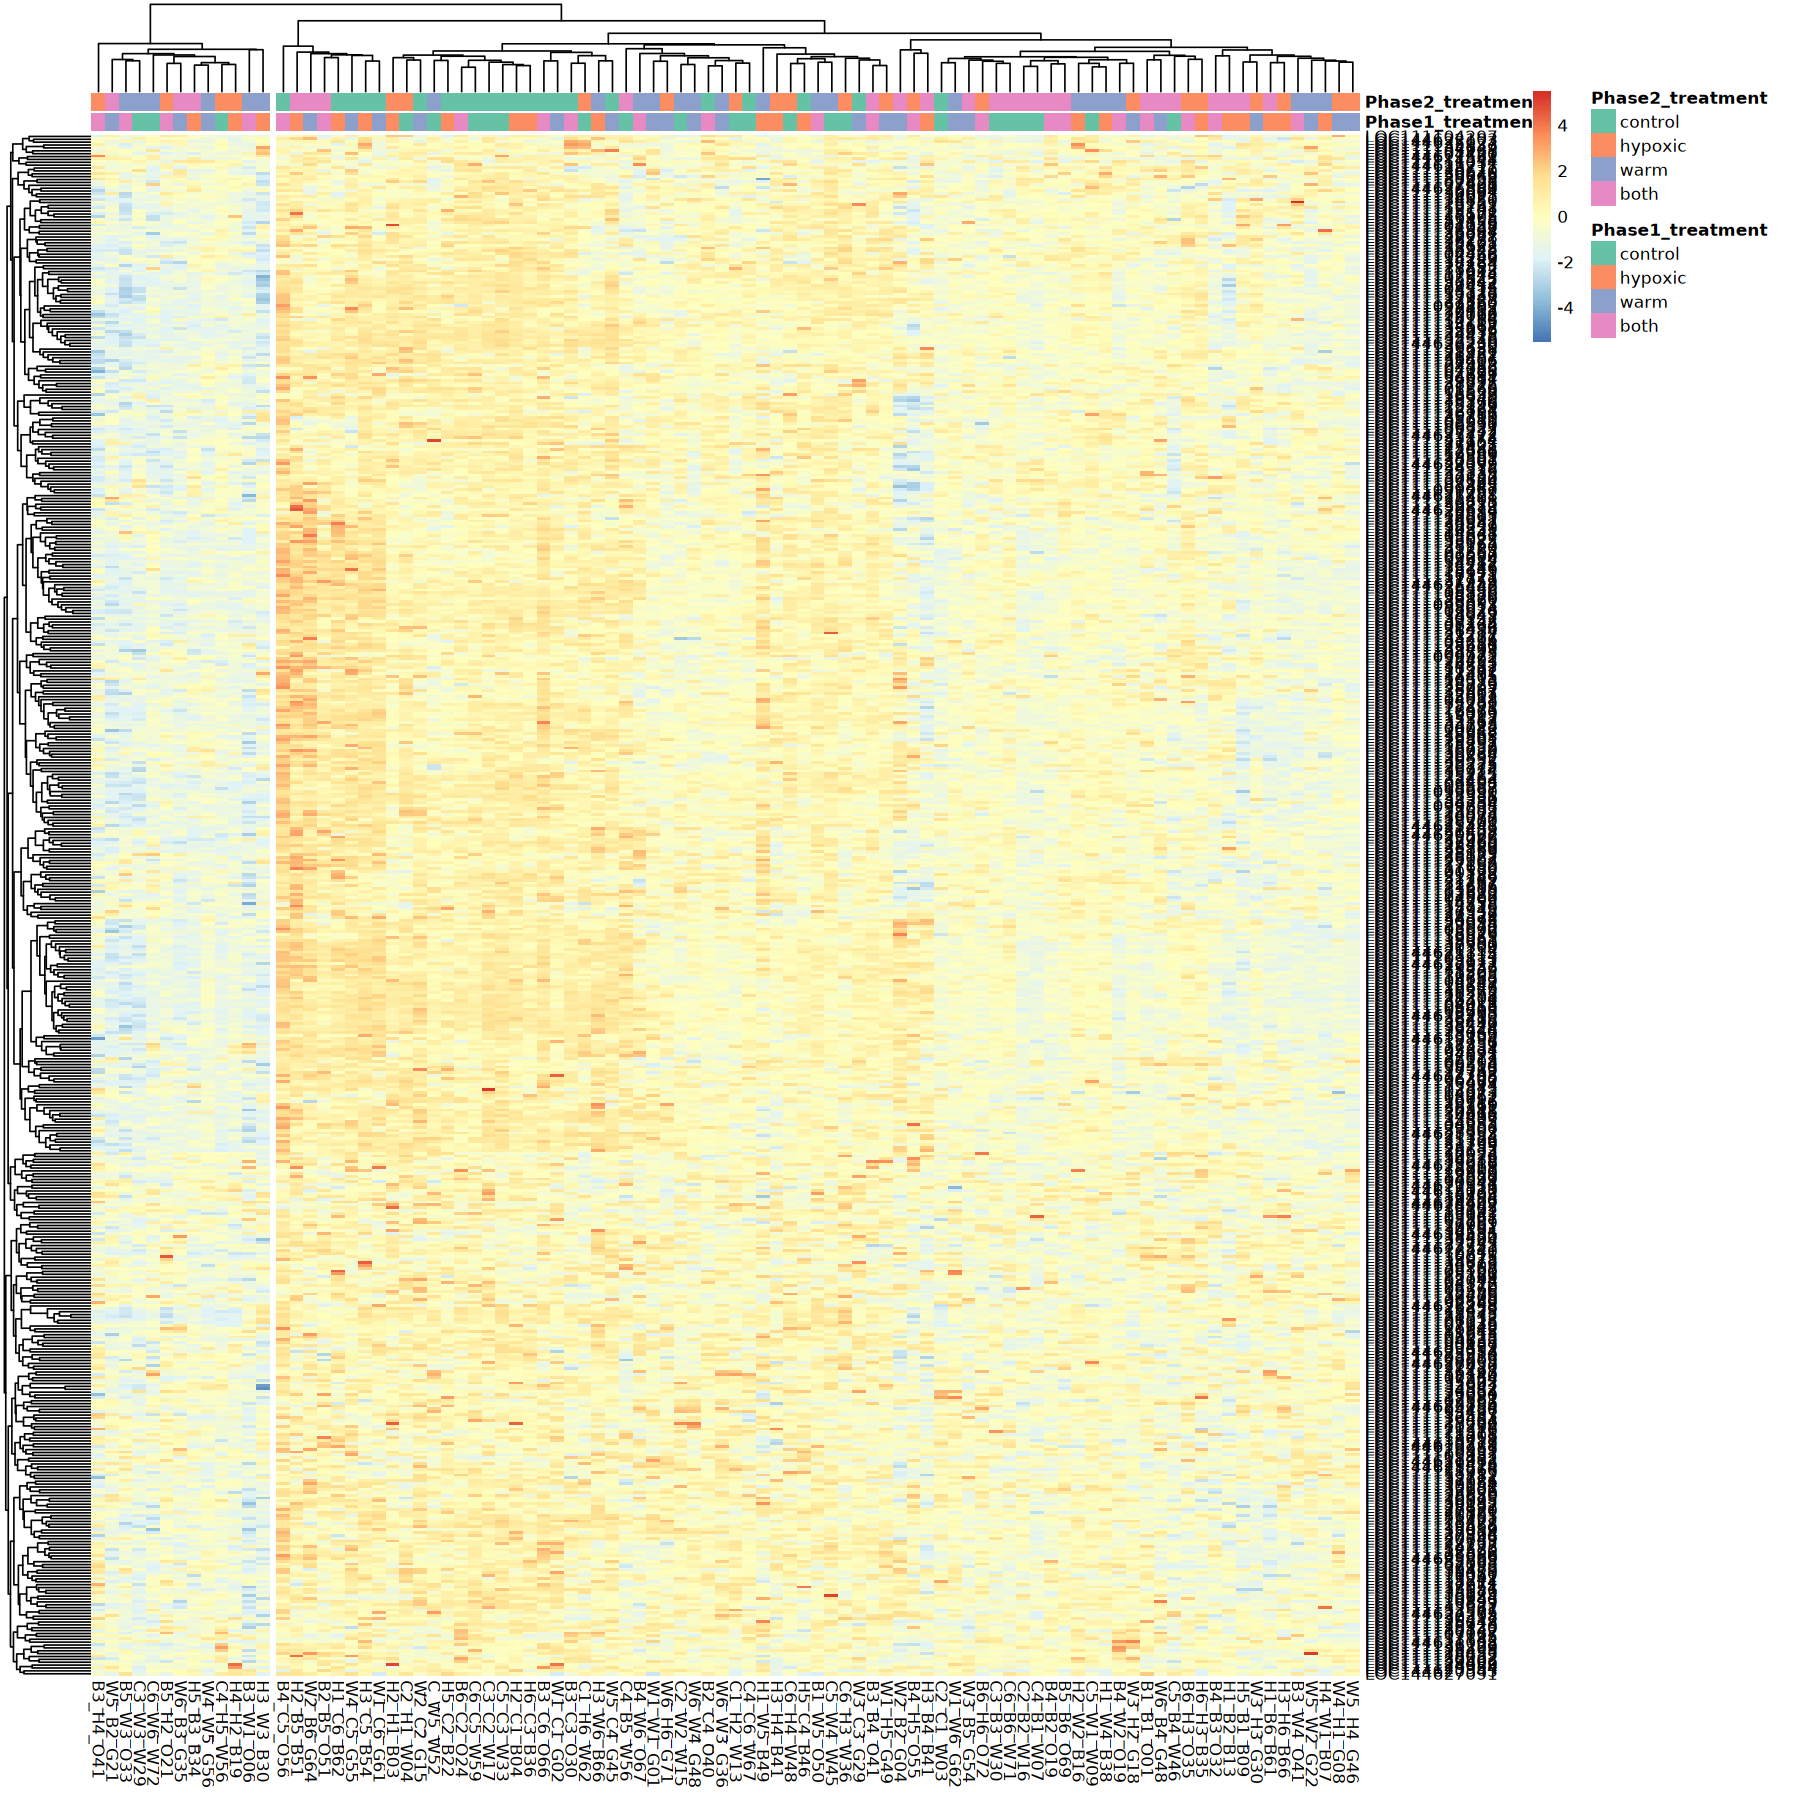

In [49]:
options(repr.plot.height = 15, repr.plot.width = 15)

pheatmap(vst536.matrix,
     #   cluster_cols = FALSE,
       annotation_col = annotation,
         annotation_colors = annotation_colors,
        # cutree_rows = 5, 
         cutree_cols = 2,
         scale = 'row' # standardizes each gene separately across samples
        ) 

so we see a clutering of samples with low expression in most of these genes - these samples experienced phase 2 warm, hypoxic, or both but NOT control

it looks like the majority of the control oysters cluster together (pink bars) and have higher expression in these genes

but I wonder if the phase 1 treatment is influencing this clustering pattern at all ... since we're ignoring the phase 1 treatment here

I went back and added the phase 1 treatment annotation to the heatmap and it's a little harder to parse out what's going on

#### vst heatmap in phase 1
interested to see what these same genes look like in the phase 1 oysters

In [55]:
p1_vst.matrix <- p1_vst %>%
pivot_wider(
    names_from = Sample,
    values_from = vst_expr) %>%
column_to_rownames('Gene')

p1_vst.matrix <- p1_vst.matrix[rownames(p1_vst.matrix) %in% vst536$Gene, ]

dim(p1_vst.matrix)
head(p1_vst.matrix)

[1] 536  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,10.821178,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,6.804587,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
LOC111105167,8.196331,7.189715,5.806396,7.503663,6.982631,6.660921,5.806396,5.806396,7.421640,6.978656,⋯,6.849611,5.806396,7.040880,5.806396,6.888116,6.947474,8.036163,6.717943,5.998381,6.237491
LOC111103981,10.400039,9.965668,8.757215,9.996500,9.855715,10.617135,9.782859,9.461734,9.691611,10.085876,⋯,9.848879,9.254741,9.600839,11.573201,9.973789,10.760633,10.894354,9.844859,10.731349,9.632776
LOC111104297,7.031961,6.132500,6.413787,6.890652,6.291005,6.948070,5.806396,6.514412,6.520724,6.948406,⋯,7.523867,6.926428,6.507428,6.118598,5.806396,7.047173,7.763553,6.663152,6.466175,6.843795
LOC111104038,10.509486,9.920636,9.222650,9.830271,10.190310,11.050758,9.686566,9.821720,10.125787,10.347979,⋯,10.402606,9.597827,9.342614,9.709018,10.510050,11.027405,10.692797,10.327030,10.379714,9.438557


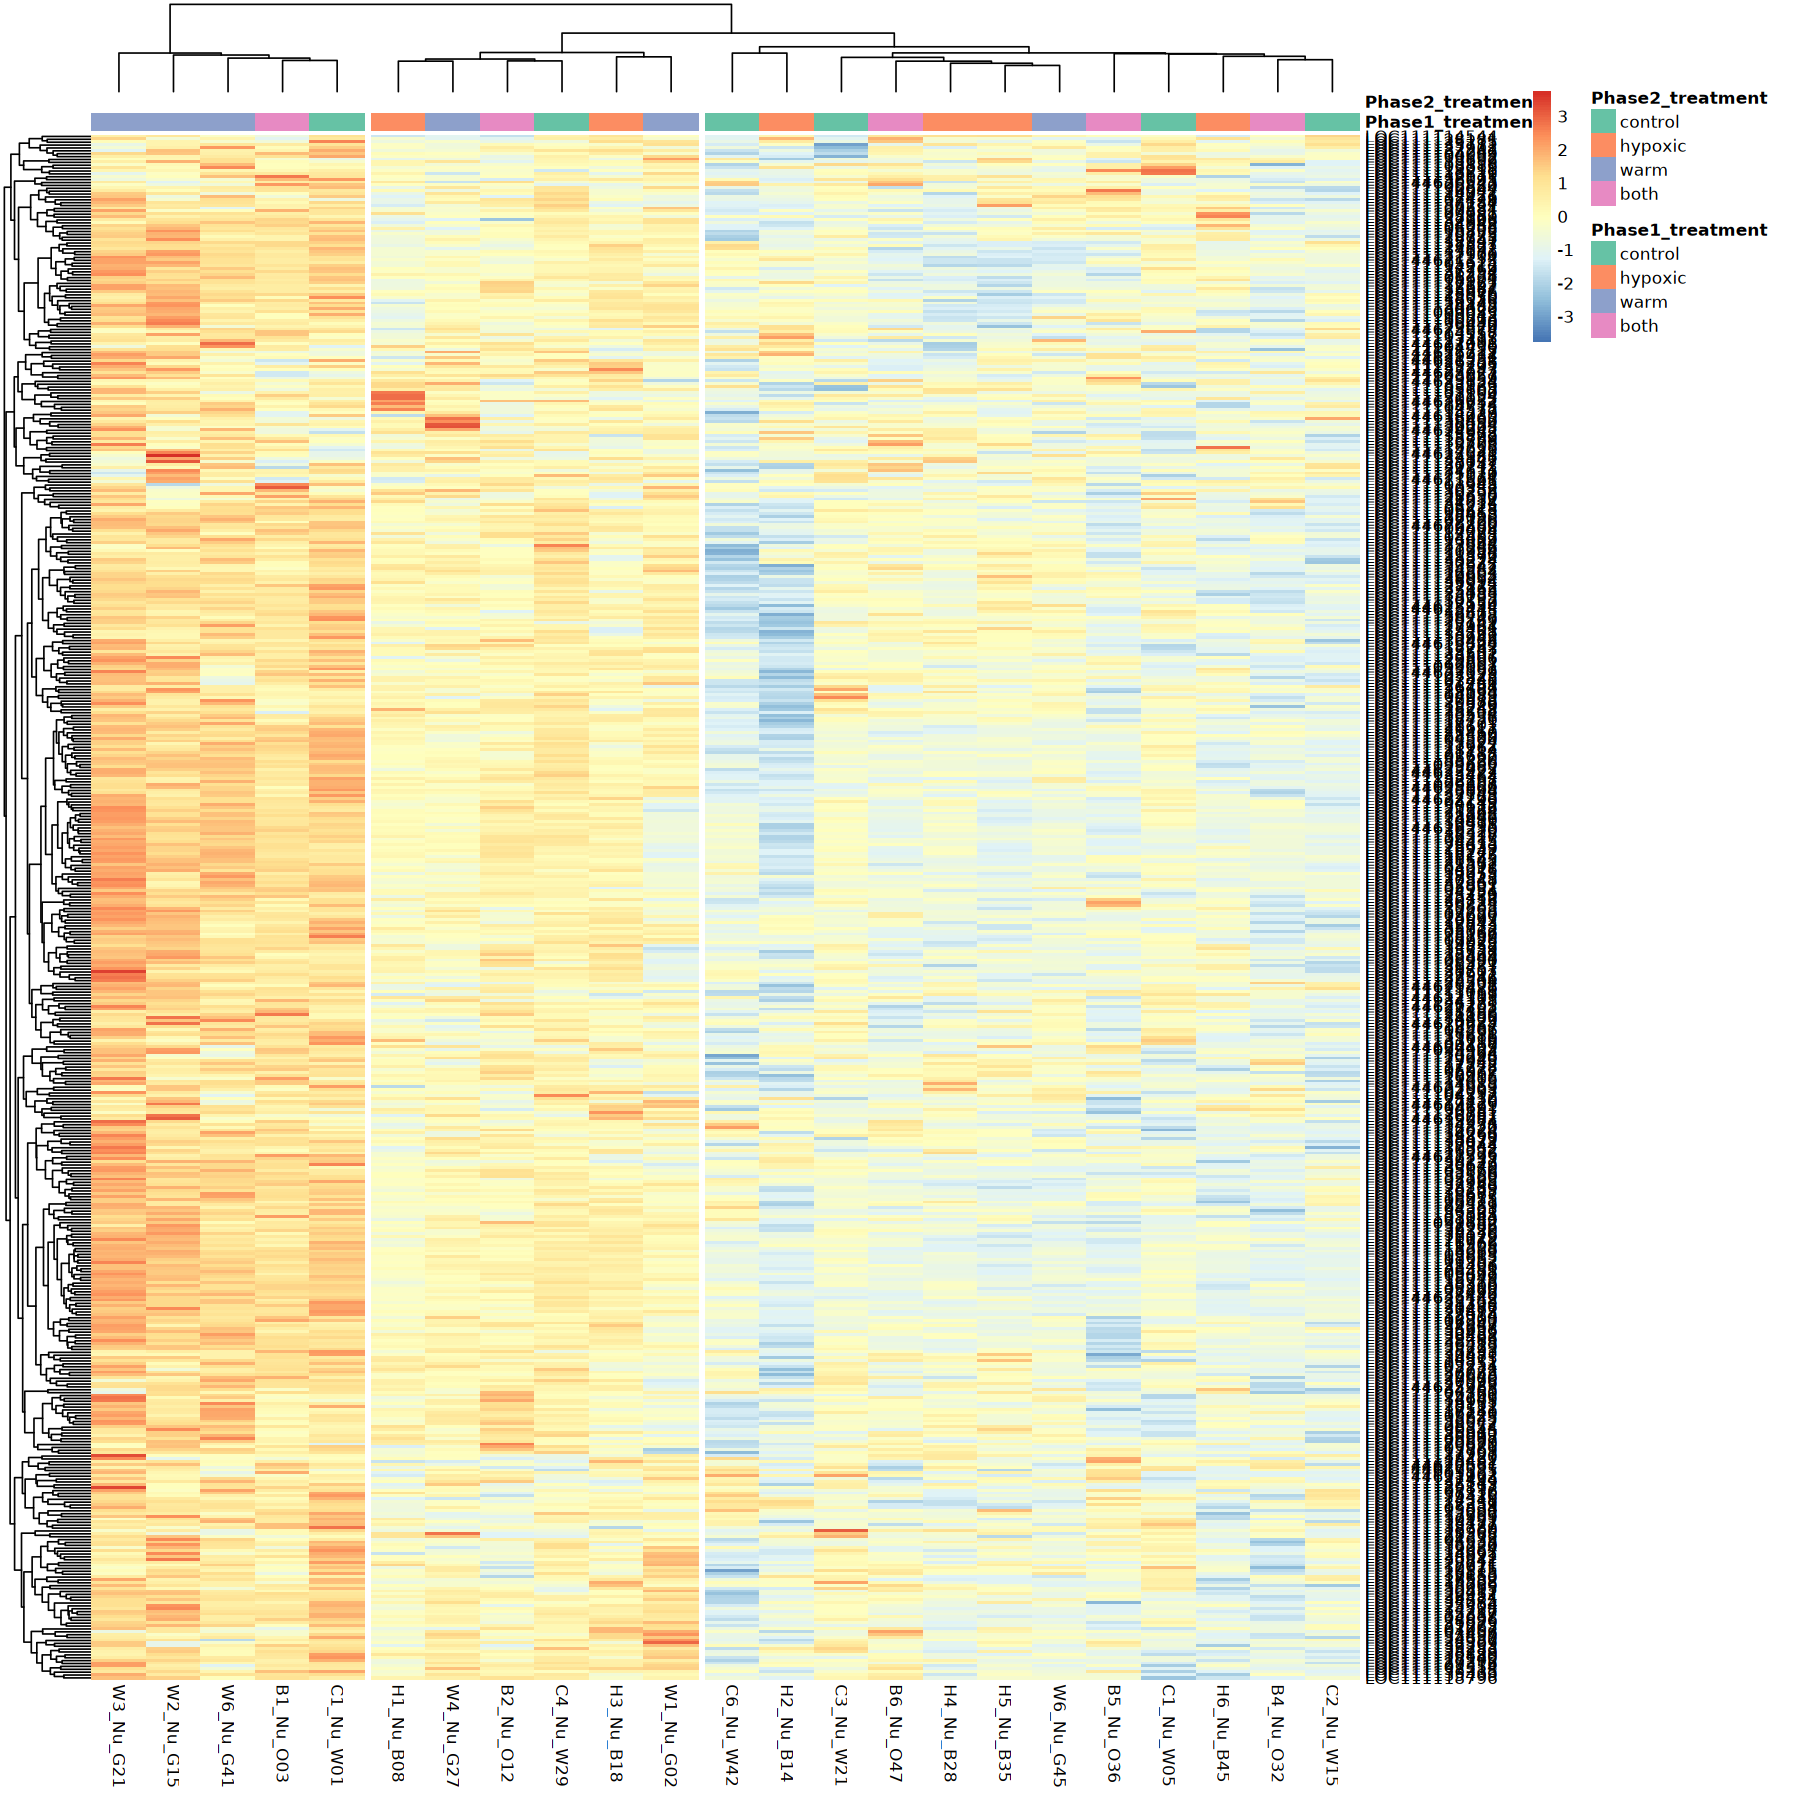

In [57]:
pheatmap(p1_vst.matrix,
     #   cluster_cols = FALSE,
       annotation_col = annotation,
         annotation_colors = annotation_colors,
        # cutree_rows = 5, 
         cutree_cols = 3,
         scale = 'row' # standardizes each gene separately across samples
        ) 

see clustering of the warm treatment

if I go back to the phase 2 oysters, the oysters that experienced phase 1 warm are not clumped together, so the response depends on the combination of stressors/environment experienced later in life

having a new thought! what if the genes are split between modules that separate shell growth and warm treatment? should check out the other phase 2 modules (like brown, which had the second most shared genes with the phase 1 blue module)

### phase 1 black module
negatively correlated with phase 1 temperature (lower expression in oysters that experienced warming stress - regardless of DO stress experienced)

In [20]:
p1black <- p1_geneInfo %>% filter(ModuleColor == 'black')
dim(p1black)
head(p1black)

p1black.geneList <- p1black %>% pull(Gene)
head(p1black.geneList)

[1] 528  34

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.421788504,-0.3630726,-0.28138410,-0.24659525,⋯,-0.2452065,-0.142577390,-0.167741192,0.3429301,0.31439017,-0.06523957,0.07719106,-0.1538004,0.22565913,0.02356195
2,LOC111099738,GO:0004930;GO:0007186;GO:0016020,black,-0.08273360,0.147594917,0.24371230,-0.196114933,-0.3920881,-0.01919558,-0.16480773,⋯,-0.4899206,0.166762787,0.004757238,0.5444832,0.46685696,0.01267256,0.18997738,-0.2938395,0.05995125,-0.30668452
3,LOC111099835,GO:0005634;GO:0008380,black,-0.39188651,-0.478648187,-0.33510763,0.351273861,0.1424555,0.31430158,0.40975621,⋯,-0.1091727,0.141825060,0.067795374,0.1916994,0.09996815,0.32681483,-0.02753824,-0.1211970,-0.15838707,-0.10048379
4,LOC111099841,GO:0005515,black,0.06120461,0.096080763,0.01561577,-0.408359068,-0.4729372,-0.21171277,-0.41980651,⋯,-0.2561215,-0.001597308,-0.302603788,0.8947988,0.38675285,-0.32853908,-0.34127155,-0.4522404,0.07962358,-0.26282410
5,LOC111099859,GO:0004930;GO:0005886;GO:0007189,black,-0.18744300,-0.228580754,-0.13899700,0.023788897,-0.3104625,0.18133998,-0.07676647,⋯,-0.2243644,0.137914226,-0.101343847,0.5154335,0.34176820,0.26731277,-0.25297559,-0.3958411,-0.01618283,-0.22166838
6,LOC111099899,GO:0005515,black,-0.08056227,-0.168325540,-0.14493627,-0.008030427,-0.1517034,0.06703816,-0.22400799,⋯,0.1654491,0.112108009,-0.041290479,0.4160596,0.04112691,-0.09089483,-0.41273624,-0.2680434,-0.18956999,-0.27514193


[1] "LOC111099037" "LOC111099738" "LOC111099835" "LOC111099841" "LOC111099859"
[6] "LOC111099899"

now looking for overlap in phase 2 oysters

In [63]:
p2_inp1Black <- p2_geneInfo[p2_geneInfo$Gene %in% p1black.geneList, ]

length(unique(p2_inp1Black$Gene))
head(p2_inp1Black)

[1] 524

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
36,LOC111099738,GO:0004930;GO:0007186;GO:0016020,brown,0.22962457,0.24562275,0.16481643,0.093667252,0.10813495,0.04973285,0.137039724,⋯,-0.28634395,-0.12984537,-0.16721526,-0.051264801,0.30376035,0.015677510,-0.20457667,-0.23548523,0.44193854,-0.054382666
59,LOC111099835,GO:0005634;GO:0008380,red,0.03821863,-0.01681051,-0.06157750,-0.001567234,0.05444797,-0.02896741,0.116804172,⋯,-0.05436711,0.14911594,0.04693749,0.167782095,0.14022966,0.132893445,0.05362145,0.01380975,0.24395784,0.075917075
60,LOC111099841,GO:0005515,red,-0.16094210,-0.23476674,-0.13322361,-0.034000186,0.09067173,-0.08302960,0.138466106,⋯,-0.07217918,0.26676236,0.40048097,0.851103463,0.01981853,-0.043678583,-0.04461755,0.05099748,0.18412229,-0.008906353
65,LOC111099859,GO:0004930;GO:0005886;GO:0007189,turquoise,0.06923403,0.06859688,0.05902856,-0.072550785,-0.12579695,-0.01749600,0.004920105,⋯,-0.06633480,-0.08086490,-0.23909830,-0.004466274,-0.03565659,-0.242720442,-0.23597538,0.08014000,0.22408449,0.224080848
72,LOC111099899,GO:0005515,blue,0.08795013,0.12139705,0.05354208,0.179488983,0.25646286,0.07066913,0.175268161,⋯,0.19102501,0.13859202,0.05677166,-0.177781779,-0.16042248,-0.009906931,-0.02693288,0.01090190,-0.09985699,-0.139806605
91,LOC111099981,GO:0005515,yellow,0.02373273,-0.05539248,-0.15885213,0.000540828,0.08050871,-0.03966446,0.082854272,⋯,0.28043283,-0.02140278,0.25769525,-0.025589541,-0.19505715,-0.073030007,-0.10972155,0.05175220,-0.13990841,-0.287287419


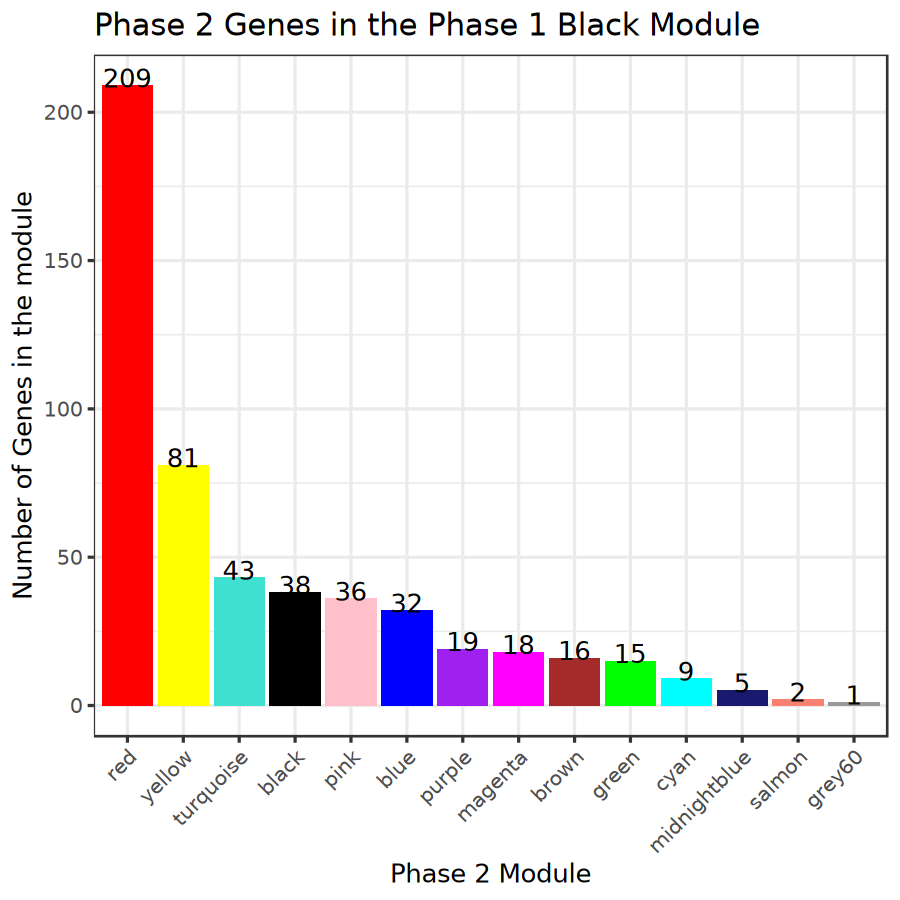

In [62]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

ggplot(p2_inp1Black, aes(x = fct_infreq(ModuleColor), fill = ModuleColor)) +
geom_bar() + 
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_fill_identity() +
labs(x = 'Phase 2 Module',
     y = 'Number of Genes in the module',
     title = 'Phase 2 Genes in the Phase 1 Black Module')

again, almost half of the genes in the phase 1 black module are in the same module in phase 2 oysters (209 in red)

in phase 1 oysters, the black module is negatively correlated with phase 2 temp (lower expression in oysters experiencing temperature stress)

in phase 2 oysters, the red module is negatively correlated with shell and tissue growth (lower expression is associated with increased growth) and positively correlated with phase 2 both treatment (higher expression in oysters exposed to both later in life)

it's interesting that we see opposing correlations again - phase 1 neg with temp, phase 2 pos with both (which has a warming treatment)

#### vst in phase 2

In [82]:
redp2 <- p2_inp1Black %>% filter(ModuleColor == 'red')

p2_vst524.long <- p2_vst[p2_vst$Gene %in% redp2$Gene, ]

length(unique(p2_vst524.long$Gene))
head(p2_vst524.long)

# convert to wider format
p2_vst524.matrix <- p2_vst524.long %>%
pivot_wider(names_from = Sample,
            values_from = vst_expr) %>%
column_to_rownames('Gene')

head(p2_vst524.matrix)

[1] 209

Gene,Sample,vst_expr
<chr>,<chr>,<dbl>
LOC111104088,B1_B1_O01,11.28406
LOC111104088,B1_W5_O50,10.12040
LOC111104088,B2_B5_O51,11.04012
LOC111104088,B2_C4_O40,10.47440
LOC111104088,B3_B4_O41,10.67425
LOC111104088,B3_C3_O30,10.07806


,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111104088,11.284061,10.120397,11.040124,10.474399,10.674255,10.078056,10.814493,10.887750,10.676984,10.518476,⋯,10.707134,10.563641,10.562182,10.477369,11.072393,10.554146,10.967936,10.712096,11.138351,11.133886
LOC111105159,9.128442,8.483578,8.649685,8.607067,8.715239,8.599817,8.483578,8.483578,8.483578,8.483578,⋯,9.159101,8.483578,8.483578,9.195107,8.483578,8.483578,8.599334,8.563742,8.819709,8.676413
LOC111105474,8.717654,8.591535,9.181861,8.685132,8.729259,8.565783,8.678540,8.483578,8.483578,8.635862,⋯,9.023710,8.483578,8.603573,9.058242,8.974163,8.594679,8.875028,8.596932,8.483578,9.053415
LOC144622110,10.870560,9.940344,10.660974,10.367749,9.960867,10.567213,10.524306,10.307037,10.177375,10.099451,⋯,10.629676,10.486300,10.613735,10.139980,10.250347,9.850640,10.446331,10.463750,10.058451,9.842135
LOC111104395,9.310581,8.788431,9.117835,8.685132,8.483578,8.483578,8.785292,8.483578,8.483578,8.591284,⋯,8.757686,8.711924,8.691295,9.415055,9.110768,8.705615,8.899610,8.822945,8.957876,8.756085
LOC111104417,9.543596,8.591535,9.510273,8.777124,8.625536,8.684801,8.570821,8.483578,8.822612,8.653817,⋯,9.023710,8.741114,8.653227,9.304757,9.053794,8.562148,8.742139,8.563742,8.734366,8.483578


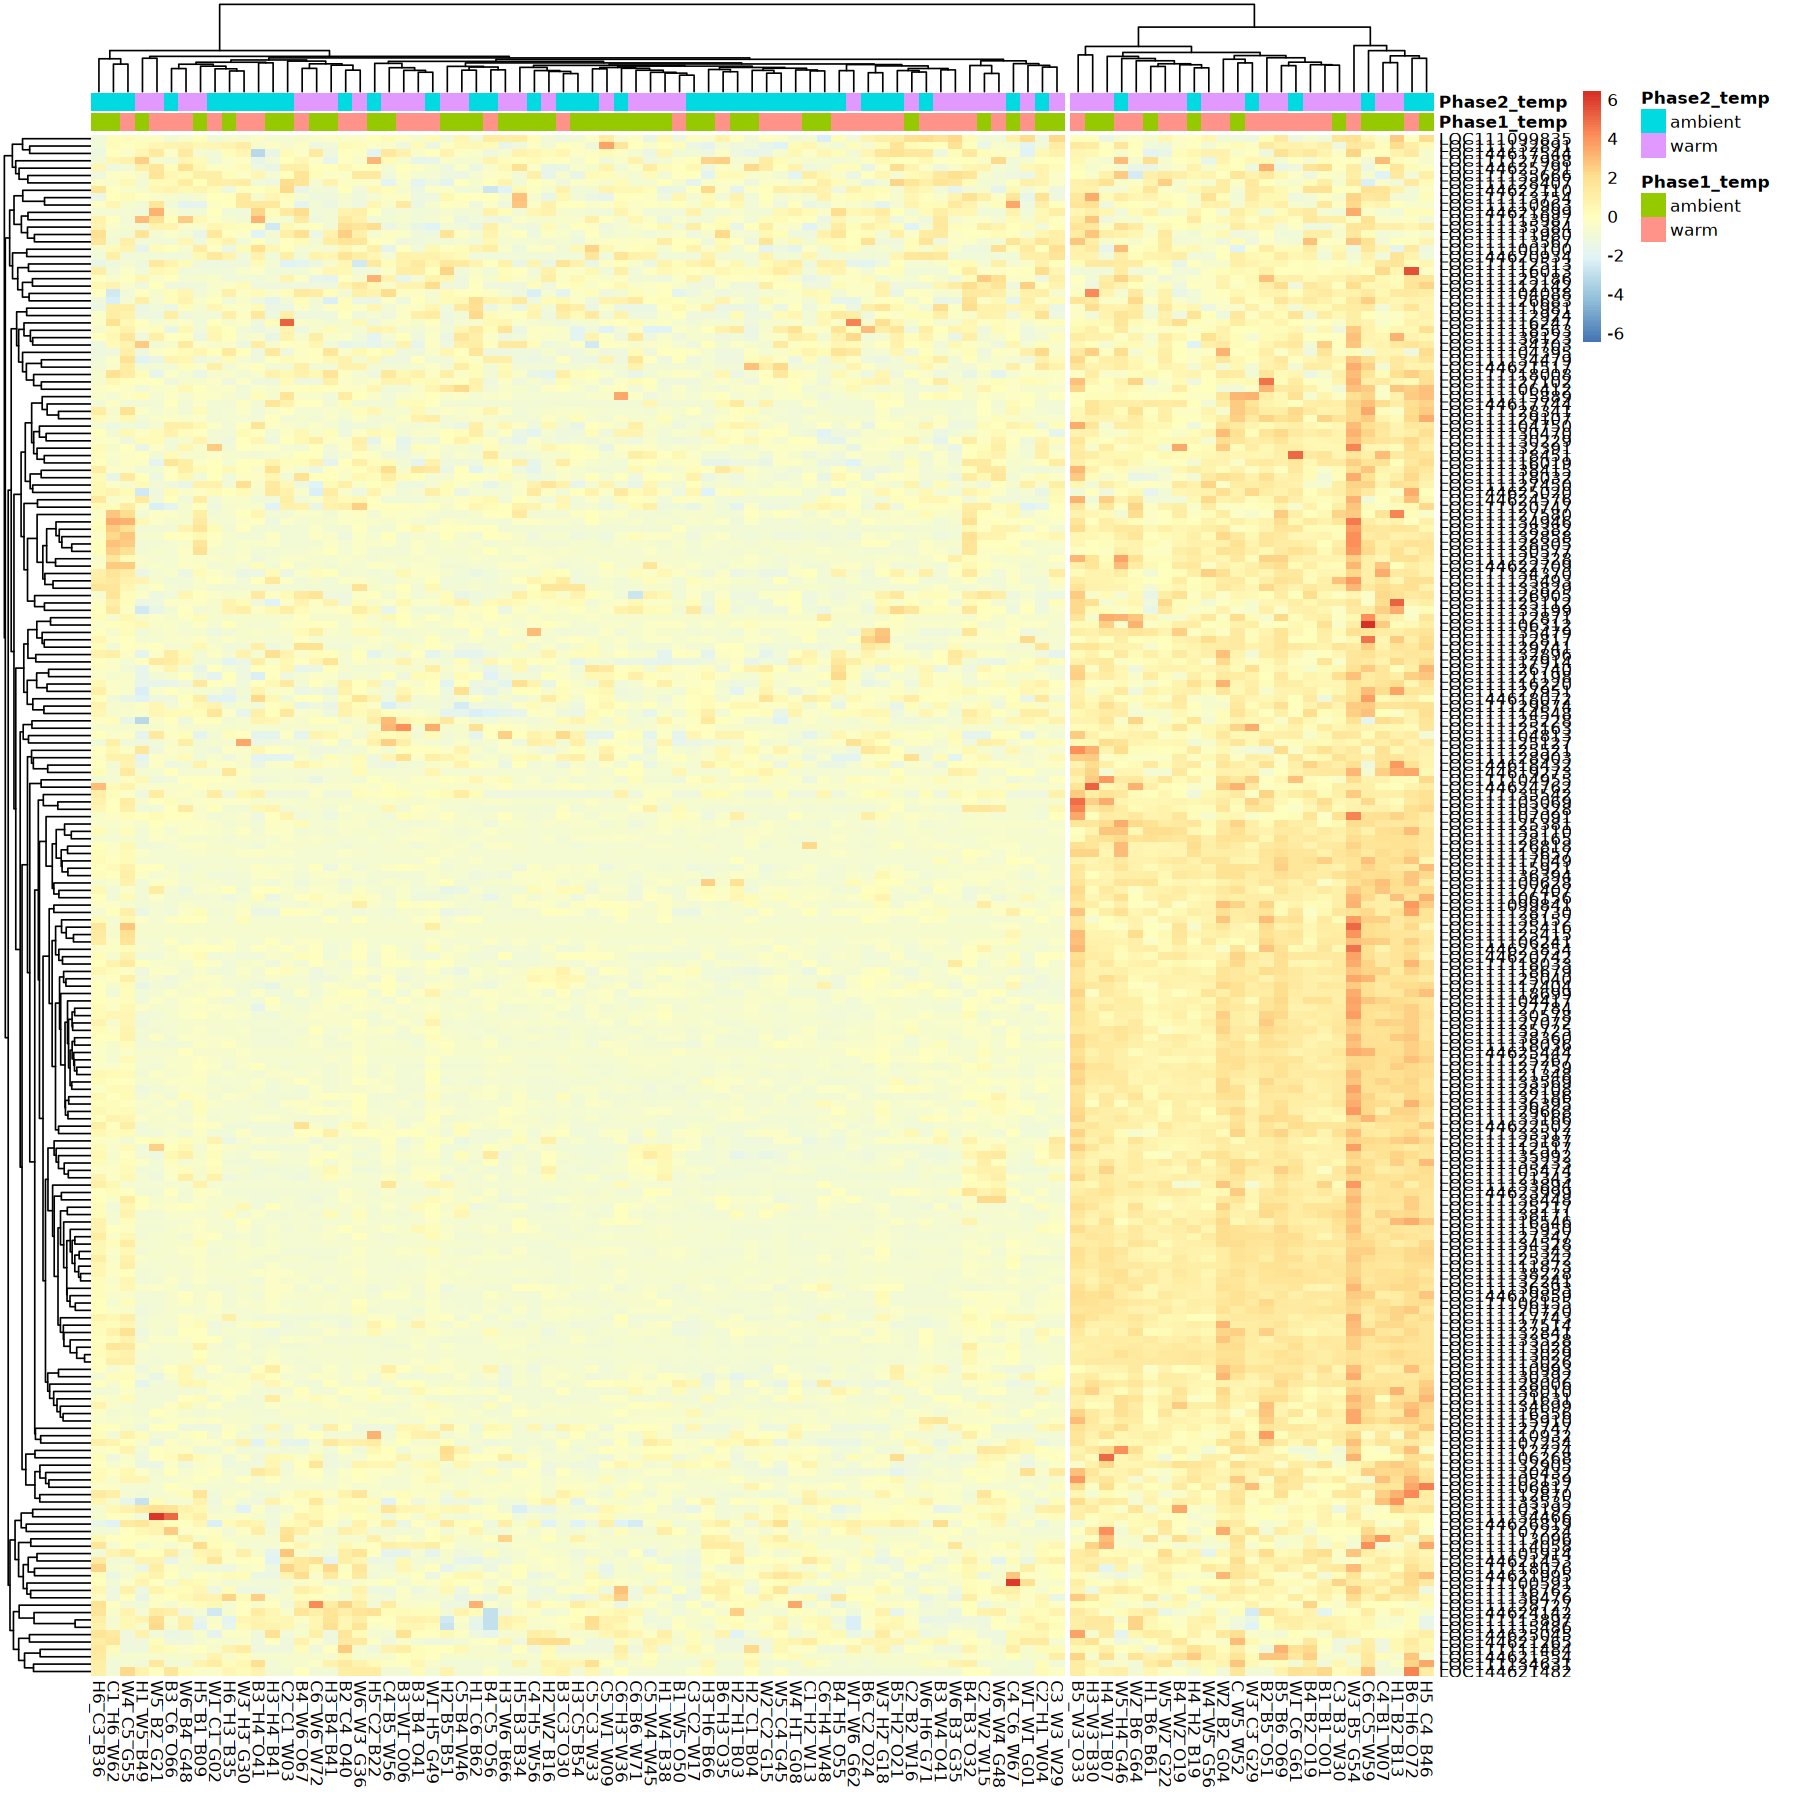

In [83]:
options(repr.plot.height = 15, repr.plot.width = 15)

annotation_temp <- meta2 %>%
  dplyr::select(Sample, Phase1_temp, Phase2_temp) %>%
  column_to_rownames("Sample") 

pheatmap(p2_vst524.matrix,
         annotation = annotation_temp,
         cutree_cols = 2, 
         scale = 'row' # standardizes each gene separately across samples
         )

okay! so the phase 2 warm temp samples are clustering and have higher expression - and it seems like most of them also experienced early exposure to warm temp stress as well - interesting!!

also looks like the samples that cluster in here that are *not* phase 2 warm temp had a phase 1 warm temp! (6 samples that are not phase 2 warm temp, of those, 4 of them had a phase 1 warm temp)